**Simple GAN Implementation (PyTorch**)

**1. Model Architecture**


*Generator (G)*

Input: random noise vector (latent space)

Output: fake image (28×28)


*Discriminator (D)*

Input: image (real or fake)

Output: probability (real or fake)

In [1]:
import torch
import torch.nn as nn

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

2. Training Process

In [2]:
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Hyperparameters
lr = 0.0002
epochs = 20
batch_size = 32
z_dim = 100


# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Models
G = Generator(z_dim)
D = Discriminator()

# Optimizers
opt_G = optim.Adam(G.parameters(), lr=lr)
opt_D = optim.Adam(D.parameters(), lr=lr)

# Loss
criterion = nn.BCELoss()

Training Loop

In [3]:
for epoch in range(epochs):
    for real, _ in loader:
        real = real.view(-1, 784)

        # Labels
        real_labels = torch.ones(real.size(0), 1)
        fake_labels = torch.zeros(real.size(0), 1)

        # -------- Train Discriminator --------
        noise = torch.randn(real.size(0), z_dim)
        fake = G(noise)

        loss_real = criterion(D(real), real_labels)
        loss_fake = criterion(D(fake.detach()), fake_labels)
        loss_D = loss_real + loss_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # -------- Train Generator --------
        noise = torch.randn(real.size(0), z_dim)
        fake = G(noise)

        loss_G = criterion(D(fake), real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {loss_D:.4f}, Loss G: {loss_G:.4f}")

Epoch [1/20] Loss D: 0.1071, Loss G: 3.8829
Epoch [2/20] Loss D: 0.2210, Loss G: 3.6271
Epoch [3/20] Loss D: 0.7171, Loss G: 3.2126
Epoch [4/20] Loss D: 0.2404, Loss G: 6.3882
Epoch [5/20] Loss D: 0.8039, Loss G: 3.0467
Epoch [6/20] Loss D: 0.2435, Loss G: 5.3782
Epoch [7/20] Loss D: 0.1816, Loss G: 3.1151
Epoch [8/20] Loss D: 0.2775, Loss G: 6.2882
Epoch [9/20] Loss D: 0.6040, Loss G: 3.7523
Epoch [10/20] Loss D: 0.4160, Loss G: 5.0013
Epoch [11/20] Loss D: 0.1239, Loss G: 2.2847
Epoch [12/20] Loss D: 0.3176, Loss G: 3.2953
Epoch [13/20] Loss D: 0.2754, Loss G: 3.7982
Epoch [14/20] Loss D: 0.9918, Loss G: 5.4599
Epoch [15/20] Loss D: 0.7462, Loss G: 3.8233
Epoch [16/20] Loss D: 0.4595, Loss G: 2.7724
Epoch [17/20] Loss D: 0.5272, Loss G: 4.5167
Epoch [18/20] Loss D: 0.5188, Loss G: 3.8540
Epoch [19/20] Loss D: 0.5678, Loss G: 1.2911
Epoch [20/20] Loss D: 0.7495, Loss G: 2.0128


Generated Images

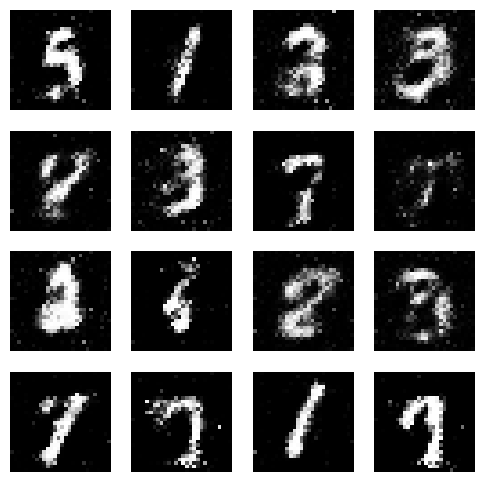

In [4]:
import matplotlib.pyplot as plt

noise = torch.randn(16, z_dim)
fake_images = G(noise).view(-1, 28, 28).detach()

fig, axes = plt.subplots(4, 4, figsize=(6,6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_images[i], cmap='gray')
    ax.axis('off')

plt.show()

**4. Observations**

At early epochs, generated images appear random and noisy
As training progresses, the generator learns digit-like structures
The discriminator improves at distinguishing real vs fake, providing better feedback

Training may become unstable if one network learns faster than the other

Final outputs resemble MNIST digits but may lack sharpness compared to real images